# Block C, Year 1: Responsible AI Template

Name: Asma moghimi

Number: 240791

## Task 2.2: Identify and Describe Bias

##### Note for running the bias analysis code:
The analysis uses two JSON files from the ImSitu dataset: train.json and imsitu_space.json. These files, along with the filtering code, are available in my GitHub repository under the ‘Deliverables’ folder. Please make sure they are placed in the same directory as the notebook to ensure the code runs correctly.

[https://github.com/BredaUniversityADSAI/2024-25c-fai1-adsai-AsmaMoghimi240791/tree/main/Deliverables/bias_analysis_Task%202.2/json]

In [4]:
import json 

with open("train.json", "r") as f:
    train_data = json.load(f)

with open("imsitu_space.json", "r") as f:
    imsitu_space = json.load(f)

print("numnber of datasets", len(train_data))
print("number of (nouns):", len(imsitu_space["nouns"]))
print("number of (verbs):", len(imsitu_space["verbs"]))
    
    

numnber of datasets 75702
number of (nouns): 82115
number of (verbs): 504


In [6]:
# Function to extract images with specific verb and agent(s)
def get_verb_agent(json_data, verb_custom, agent_custom):
    verb_list = []
    agent_list = []
    file_list = []
    
    for img_id, img_data in json_data.items():
        if img_data['verb'] == verb_custom:
            for frame in img_data['frames']:
                if 'agent' in frame and frame['agent'] in agent_custom:
                    verb_list.append(img_data['verb'])
                    agent_list.append(frame['agent'])
                    file_list.append(img_id)
                    break  # Only add once per image

    return file_list, verb_list, agent_list

# Define agent codes
woman_code = 'n10787470'
man_code = 'n10287213'

# Updated list of verbs
verbs_to_check = ['repairing', 'operating', 'packaging', 'building']

# Run analysis
for verb in verbs_to_check:
    files, verbs, agents = get_verb_agent(train_data, verb, [woman_code, man_code])
    women_count = agents.count(woman_code)
    men_count = agents.count(man_code)
    
    print(f"\nVerb: {verb}")
    print(f"Number of images with female agent: {women_count}")
    print(f"Number of images with male agent: {men_count}")



Verb: repairing
Number of images with female agent: 5
Number of images with male agent: 180

Verb: operating
Number of images with female agent: 39
Number of images with male agent: 152

Verb: packaging
Number of images with female agent: 30
Number of images with male agent: 37

Verb: building
Number of images with female agent: 1
Number of images with male agent: 76


In [7]:
import pandas as pd

# Define a function to collect data for multiple verbs and save as CSV
def create_bias_csv(json_data, verbs, agent_codes, output_csv):
    all_files = []
    all_verbs = []
    all_agents = []

    for verb in verbs:
        files, verbs_list, agents = get_verb_agent(json_data, verb, agent_codes)
        all_files.extend(files)
        all_verbs.extend(verbs_list)
        all_agents.extend(agents)

    df = pd.DataFrame({
        "file_name": all_files,
        "verb": all_verbs,
        "agent": all_agents
    })

    df.to_csv(output_csv, index=False)
    print(f"CSV file saved as {output_csv}")
    return df

# Define verbs and agents
verbs_to_check = ['repairing', 'operating', 'packaging', 'building']
agent_codes = ['n10787470', 'n10287213']  # woman, man

# Run it
create_bias_csv(train_data, verbs_to_check, agent_codes, "bias_analysis_results.csv")


CSV file saved as bias_analysis_results.csv


,file_name,verb,agent
0,repairing_238.jpg,repairing,n10287213
1,repairing_259.jpg,repairing,n10287213
2,repairing_32.jpg,repairing,n10287213
3,repairing_147.jpg,repairing,n10787470
4,repairing_106.jpg,repairing,n10287213
...,...,...,...
515,building_235.jpg,building,n10287213
516,building_180.jpg,building,n10287213
517,building_68.jpg,building,n10287213
518,building_118.jpg,building,n10287213


For this task, I analyzed gender representation in the ImSitu dataset because my own dataset didn’t include people. I decided to focus on industrial and production-related activities, since this connects directly to my main project about defect detection in manufacturing.

But the reason I chose verbs like repairing, operating, packaging, and building wasn’t random. As someone who grew up in an industrialized environment, I’ve always noticed how few women are visible in these spaces. Even though women are capable and present, they are often not seen—or not shown—as part of the system. That’s why I was curious to see if this same imbalance would appear in the dataset too.

I used metadata to filter images where the agent was labeled either as a man (n10287213) or a woman (n10787470). Here’s what I found:

Repairing: 5 women vs. 180 men

Operating: 39 women vs. 152 men

Packaging: 30 women vs. 37 men

Building: 1 woman vs. 76 men

The results really speak for themselves. For highly technical or physical roles like repairing and building, the presence of women is almost nonexistent. Even in operating, the difference is significant. Packaging was the most balanced, but still slightly favors men.

This is a clear example of representational harm. The dataset reflects a biased view of gender roles in industrial spaces—suggesting that only men are the default in such environments. And the problem is, when datasets like this are used to train AI systems, they learn and repeat those biases. This doesn’t just reflect inequality—it reinforces it.

In real-world applications, this could affect image classification, hiring algorithms, training simulations, or even educational content. The message becomes: "You don’t belong here"—not because it’s true, but because the data says so.

That’s why it’s important to intentionally include underrepresented groups when building datasets. Diversity isn’t just about fairness; it’s about building systems that don’t erase people. We need datasets that show the world as it should be, not just as it has been.

[https://github.com/BredaUniversityADSAI/2024-25c-fai1-adsai-AsmaMoghimi240791/blob/main/Deliverables/bias_analysis_Task%202.2/bias_analysis_results.csv]
This is csv of the result 

## Task 2.3: Propose Individual Fairness Method

In Task 2.2, I found clear gender bias in the ImSitu dataset. Women were heavily underrepresented in industrial roles like repairing and building, while men dominated those images. This creates representational harm by reinforcing the stereotype that only men belong in technical or factory-related jobs. The sensitive attribute in this case is gender.

To address this, I propose using the Fairness Through Awareness method. Instead of ignoring gender, this approach acknowledges the imbalance and aims to fix it by adding more representative data or adjusting the dataset weights.

This could mean:

Adding more images of women in industrial roles like repairing or operating.

Reweighting existing images of women in these roles, so the model gives them more influence during training.

I chose this method because it directly addresses the root of the problem: not enough representation. Since we’re working with image data, we can’t just “remove” gender like in tabular data. Instead, we need to intentionally include what’s missing.



## Task 2.4: Create Infographic; Group Fairness Metrics

__1. Strengths__

[Mohammadali jaberi - 244437]
- [The infographic looks really nice, and it’s clear that she put a lot of effort into creating it. The use of stickers and visual elements makes the design more appealing. She did a great job with the overall layout — it’s clean, organized, and easy to follow. The information is presented in a simple and clear way, making it easy to read and understand. Overall, it’s an engaging and well-designed infographic that shows strong attention to detail and creativity.]
- [My infographic clearly communicates the concept of group fairness using a relatable real-world example. By telling the story of Maya, a factory worker affected by biased predictions, the abstract theory becomes more human and emotionally engaging. The infographic explains each of the three group fairness metrics—Demographic Parity, Predictive Parity, and Equal Opportunity—with a balance of definitions, visuals, and simple explanations. The layout is clean and readable, with a logical flow from the problem to possible solutions. I believe the strongest part is how it combines storytelling with fairness theory to help others quickly grasp why this topic matters in practice.]

__2. Areas for Improvement__

- [Mohammadali jaberi - 244437]
- [She did a great job on her infographic — the content is clear, and it’s easy to understand. The layout is simple and well-organized, which makes it user-friendly. However, I think she could enhance it even more by playing with colors or adjusting the theme to make it more visually engaging. Adding some contrast or experimenting with different color schemes could help draw more attention to key information and make the overall design more dynamic. Right now, it’s effective in terms of clarity, but a bit more creativity in the visual style could make it even more eye-catching and memorable.]
- [While the infographic is informative and visually appealing, there are a few areas that could benefit from refinement. Some headings and sections could use more contrast or visual hierarchy to guide the viewer’s eyes more effectively. For example, the titles of each metric could be slightly larger or highlighted with icons to help them stand out. Additionally, the infographic might benefit from breaking up longer paragraphs into shorter bullet points or callouts, making it easier to skim. Lastly, while the story of Maya is strong, adding a clearer visual indicator of how the system changed after applying fairness principles could help emphasize the positive outcome more clearly.]

__3. Next Steps for Improvement__

- [After reviewing the feedback and reflecting on the design, I believe the current version of my infographic already meets its goal effectively. The balance between text and visuals feels appropriate for explaining complex concepts like group fairness without oversimplifying. While there were suggestions to add comparison charts or reduce text, I chose to keep the current structure because it maintains a smooth narrative flow and supports comprehension through storytelling. Instead of changing the layout or content, my next step is to focus on clearly presenting and explaining the infographic during evaluation, ensuring the message remains accessible and engaging to different audiences.]

__4. Reflection__

- [Overall, I’m proud of how my infographic combines theoretical knowledge with a personal story to explain group fairness in a human-centered way. The process helped me understand how important it is to make abstract AI topics more relatable. The feedback I received made me realize that although the content is strong, visual simplification is just as important to ensure clarity. I’ve learned that storytelling really works in visual design, and in future projects I want to build even more on that strength while continuing to make my layouts more user-friendly and focused.]

__5. Infographic__
- [[Group_Fairness_Infographic_Asmamoghimi_240791.pdf](https://github.com/BredaUniversityADSAI/2024-25c-fai1-adsai-AsmaMoghimi240791/blob/main/Deliverables/Group_Fairness_Infographic_Asmamoghimi_240791.pdf)]

## Task 2.5: Apply an Explainable AI Method to the Image Classifier

__Virtual Environment:__
- [https://github.com/BredaUniversityADSAI/2024-25c-fai1-adsai-AsmaMoghimi240791/blob/main/Deliverables/xai_requirements.txt]

This is the CNN model I used for Iteration 2. It consists of three convolutional layers with ReLU activations and max pooling, which help the model learn important features from the fabric images while reducing dimensionality. After that, I used a flatten layer to prepare the data for the dense layers. I added a dense layer with 128 units, followed by a dropout layer to prevent overfitting, and finished with a sigmoid output layer for binary classification.
I originally tried a different version of this model, but it caused unexpected shape and loading errors — possibly due to the way it was saved with Keras. To avoid these issues, I recreated the architecture from scratch using a simpler, cleaner structure. This version gave better results and was more stable, which is why I selected it for Grad-CAM and explainability.

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_v2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])


2025-04-09 19:47:15.058288: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from tensorflow.keras.optimizers import Adam

cnn_v2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [3]:
cnn_v2.load_weights('/Users/apple/Documents/GitHub/2024-25c-fai1-adsai-AsmaMoghimi240791/Deliverables/cnn_iteration2_model.h5')


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (128, 128)
batch_size = 32

dataset_path = "/Users/apple/Documents/GitHub/2024-25c-fai1-adsai-AsmaMoghimi240791/split_dataset"
test_path = f"{dataset_path}/test"

val_test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


Found 62 images belonging to 2 classes.


In [5]:
test_generator.reset()
x_sample, y_sample = test_generator.next()

x_img = x_sample[0:1]
y_true = y_sample[0]

print(f"True label: {int(y_true)}")


True label: 0


This block of code generates a Grad-CAM heatmap to visualize which parts of an image the model focused on when making its prediction. First, I used my trained CNN model to predict on one image from the test set. Then, I identified the last convolutional layer in the model and used TensorFlow's GradientTape to calculate the gradients of the predicted class with respect to the output of that layer.
After processing and normalizing the gradients, I created a heatmap showing the most activated regions. The final part overlays the heatmap on the original image so it's easier to visually understand where the model “looked” when deciding whether the fabric was defective or not. This method helped me analyze whether the model was attending to actual damaged areas or getting distracted by irrelevant textures or edges.

1/1 [==============================] - 0s 28ms/step
Predicted probability: 0.34


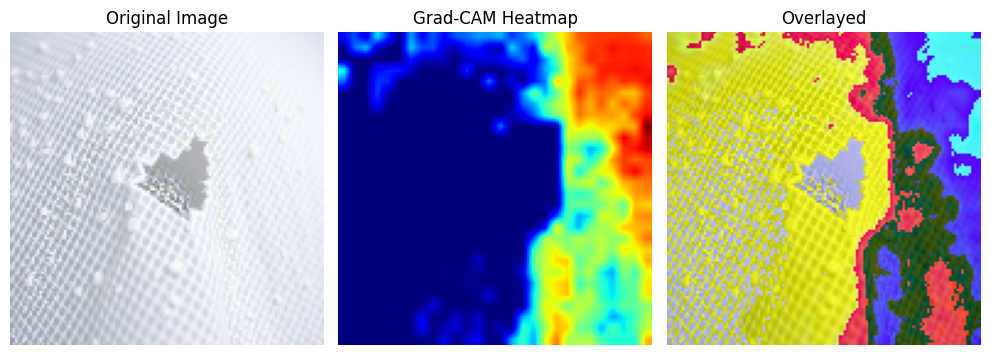

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import numpy as np


pred = cnn_v2.predict(x_img)[0][0]
print(f"Predicted probability: {pred:.2f}")

last_conv_layer_name = [layer.name for layer in cnn_v2.layers if isinstance(layer, Conv2D)][-1]
grad_model = tf.keras.models.Model(
    [cnn_v2.inputs], 
    [cnn_v2.get_layer(last_conv_layer_name).output, cnn_v2.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x_img)
    loss = predictions[:, 0]


grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

heatmap = np.maximum(heatmap, 0)
heatmap /= tf.math.reduce_max(heatmap)

heatmap = cv2.resize(heatmap.numpy(), (128, 128))

heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

original_img = x_img[0]
original_img = np.clip(original_img, 0, 1)

overlayed_img = heatmap_colored * 0.4 + original_img * 255
overlayed_img = np.uint8(overlayed_img)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlayed_img)
plt.title("Overlayed")
plt.axis("off")

plt.tight_layout()
plt.show()


- What XAI method did you choose, and why?
  
  I chose Grad-CAM because it's a visual explainable AI method made for Convolutional Neural Networks. It creates a heatmap that shows which parts of the image the model focused on when making a prediction. I picked it because my task is image-based (defective vs non-defective fabric), and I wanted to actually see what the model “looked at” during classification.




-  Can you provide an example demonstrating how the model identifies specific objects, textures, or shapes within    the images using the chosen XAI method?
  
   I tested Grad-CAM on one of the images from my test set that clearly showed a defect in the fabric. The original image showed a dark hole in the middle. However, the Grad-CAM heatmap showed that the model focused more on the edge of the fabric instead of the actual hole. This tells me that the model might be picking up patterns in the background texture or lighting rather than the damage itself.


- How can the insights from the XAI method help improve your model?
  
  
  The Grad-CAM result helped me realize that my model isn't always focusing on the correct area (the defect). It’s sometimes distracted by edges or patterns in the fabric. This is helpful because it explains why the model sometimes misclassifies defects — it may not be “looking” at the important spot. In the future, I could use these insights to improve the dataset, adjust the model to focus better, or try more targeted preprocessing to help the model learn the right features.
  